# Resting-State fMRI Analysis in R
### From Preprocessed Data to Functional Connectivity


**Authors**: 
Giulia Baracchini & Monika Doerig

**Date**: 13 Jan 2026

**License:** 
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** If this notebook uses neuroimaging tools from Neurocontainers, those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

### Citation and Resources:

#### Tools included in this workflow
__R__:
- R Core Team. (2025). R: A language and environment for statistical computing (Version 4.4.3) [Software]. R Foundation for Statistical Computing. [https://www.R-project.org/](https://www.R-project.org/)

#### Workflows this work is based on
Original work from Giulia Baracchini: 
- [Resting-state fMRI: From raw data to analyses](https://github.com/giuliabaracc/teaching_fMRI/blob/main/fMRI_restpreprocnet.html)
- [teaching_fMRI](https://github.com/giuliabaracc/teaching_fMRI/blob/main/code/Tutorial_fMRI_complete.R)


#### Dataset
__HCP__
- [3T young adults resting-state dataset](https://www.humanconnectome.org/study/hcp-young-adult/data-releases)

__Schefer parcellation__
- [ThomasYeoLab](https://github.com/ThomasYeoLab/CBIG/tree/master/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal)

## Introduction

This notebook is adapted from Giulia Baracchini's comprehensive fMRI preprocessing tutorial ([available on GitHub](https://github.com/giuliabaracc/teaching_fMRI/blob/main/fMRI_restpreprocnet.html)), which covers the essential steps of resting-state fMRI analysis from raw data preprocessing through functional connectivity analyses.

The original tutorial provides a complete pipeline covering:

1. **Standard fMRI preprocessing** - preparing raw neuroimaging data for analysis
2. **Resting-state fMRI denoising** - removing artifacts and noise from the signal
3. **Time-series extraction and parcellation** - converting voxel-level data to meaningful brain regions
4. **Functional connectivity analyses** - examining statistical relationships between brain regions

## What This Notebook Covers

While the original tutorial works with multiple subjects and uses the Schaefer 200 region-7 network parcellation, this notebook focuses on a single-subject analysis using the **Schaefer 200 region-17 network** parcellation applied to subject 101309. 

### Key Concepts

**Parcellation**: The process of grouping individual voxels into meaningful brain regions or "parcels." Instead of analyzing thousands of individual voxels, we average signals within anatomically or functionally defined regions, making our analyses more interpretable and computationally manageable.

**Functional Connectivity (FC)**: A statistical measure (typically Pearson's correlation) that quantifies how synchronously different brain regions activate during rest. The result is a region × region matrix where each entry represents the strength of correlation between two brain areas.

### Analysis Pipeline

This notebook focuses on the **analysis phase** using already preprocessed and parcellated data. Starting with clean time series data from 200 brain regions, we implement:

1. **Data normalization** - standardizing time series signals across regions
2. **Functional connectivity calculation** - computing correlation matrices between brain regions  
3. **Fisher z-transformation** - normalizing correlation values for statistical analysis
4. **Network visualization** - creating heatmaps and brain plots to visualize connectivity patterns
5. **Nodal strength analysis** - quantifying each region's overall connectivity
6. **Relationships to other measures of brain organisation** - relating connectivity patterns to brain organization gradients and gene expression patterns

The Schaefer parcellation we're using divides the brain into 200 regions across 17 functional networks, providing a good balance between spatial resolution and interpretability for resting-state connectivity analyses.

## Running R in Jupyter with Python Kernel

<div style="background-color: light-dark(#fff3cd, #4a3800); border-left: 4px solid #ff9800; padding: 15px; margin: 20px 0; color: light-dark(#856404, #ffd966);">
    <p style="color: light-dark(#856404, #ffd966);">⚠️ <strong>Run R in Jupyter Notebook:</strong> This notebook uses <strong>R magic commands</strong> (<code style="background-color: light-dark(#ffe69c, #332600); color: light-dark(#856404, #ffd966); padding: 2px 6px; border-radius: 3px;">%%R</code>) to run R code within a Python kernel environment. This approach offers several advantages:</p>
    <ul style="color: light-dark(#856404, #ffd966);">
        <li><strong>No kernel switching required</strong> - all code runs in the Python kernel</li>
        <li><strong>Seamless Python ↔ R integration</strong> - easy data exchange between languages</li>
        <li><strong>Fully automated setup</strong> - no manual kernel installation needed</li>
    </ul>
    <p style="color: light-dark(#856404, #ffd966);"><em>Note: Alternatively, Jupyter supports native R kernels, but the magic command approach keeps everything within the Python kernel for simpler workflow management.</em></p>
</div>

### Setup Steps
**1. Install R runtime and packages via mamba:**

In [1]:
# Install R runtime, Python↔R bridge, and geospatial R packages via conda
# Note: r-base provides the R runtime; we avoid r-essentials (80+ packages) to prevent solver conflicts
! mamba install -c conda-forge r-base rpy2 r-sf r-units r-s2 r-ggplot2 -y -q

In [2]:
# Set env vars before loading rpy2
# Set PROJ database path so sf can find coordinate reference systems
# (needed when r-sf is installed via conda)
import os
proj_path = os.path.join(os.environ.get("CONDA_PREFIX", "/opt/conda"), "share", "proj")
os.environ["PROJ_LIB"] = proj_path
os.environ["PROJ_DATA"] = proj_path

**2. Enable `%%R` magic commands:**

We only need to run it once for the first time. After these installations, the Jupyter Notebook now supports both Python 3 and R programming languages.

In [3]:
%load_ext rpy2.ipython

**3. Install R packages from CRAN and r-universe:**

In [ ]:
%%R
# ==============================================================================
#  Setup a User-Specific R Library and Install Packages
# ==============================================================================

# 1. Personal library path. Install into the workspace bind-mount when present
#    (roomy runner storage in CI); otherwise fall back to ~/R/library. The
#    home library sits on the container overlay layer, which runs out of
#    space while ggsegSchaefer serializes its atlas data (the install then
#    fails with "error writing to connection"); the workspace mount has room.
ws <- "/home/jovyan/workspace"
user_lib <- if (dir.exists(ws)) file.path(ws, ".r-library") else path.expand("~/R/library")
dir.create(user_lib, recursive = TRUE, showWarnings = FALSE)

# 1b. Point R's temp dir at the same roomy location, for the same reason.
r_tmp <- if (dir.exists(ws)) file.path(ws, ".rtmp") else path.expand("~/R/tmp")
dir.create(r_tmp, recursive = TRUE, showWarnings = FALSE)
Sys.setenv(TMPDIR = r_tmp, TMP = r_tmp, TEMP = r_tmp)

# 2. Add the personal library to R's library search path
.libPaths(c(user_lib, .libPaths()))

# 3. Set repositories: CRAN + ggseg r-universe
options(repos = c(
    ggseg = "https://ggseg.r-universe.dev",
    CRAN = "https://cloud.r-project.org"
))

# 4. Install required packages from CRAN
install.packages(c("remotes", "magrittr", "ggplot2", "dplyr", "tidyr", "knitr"))

# 4b. Install superheat from the CRAN archive (last version before archiving)
if (!requireNamespace("superheat", quietly = TRUE)) {
    remotes::install_version("superheat", repos = "https://cloud.r-project.org")
}

# 4c. Ensure callr (and its dependency ps) is available — remotes::install_github
#     needs callr to build packages from source in an isolated subprocess.
if (!requireNamespace("callr", quietly = TRUE)) {
    install.packages(c("ps", "callr"))
}

# 5. Install ggsegSchaefer first (latest), so its dependencies cannot later
#    overwrite the pinned ggseg below. Try r-universe, fall back to GitHub.
install.packages("ggsegSchaefer")
if (!requireNamespace("ggsegSchaefer", quietly = TRUE)) {
    message("ggsegSchaefer not found via r-universe, installing from GitHub...")
    remotes::install_github("ggseg/ggsegSchaefer", upgrade = "never")
}

# 6. Pin ggseg to the last-good v2.1.1, installed LAST. ggseg 2.2.0 (r-universe
#    latest) regressed geom_brain so aes(fill = Value) errors with object Value
#    not found. Installing ggseg last overwrites any newer ggseg pulled in as a
#    dependency above. upgrade=never leaves ggseg deps (incl. ggplot2) untouched.
remotes::install_github("ggseg/ggseg", ref = "v2.1.1", upgrade = "never", force = TRUE)

# 7. Verify the library path
print("R packages will be installed in and loaded from:")
print(.libPaths())

**4. All subsequent R code uses the `%%R` cell magic:**

Each cell containing R code must start with `%%R` to be executed as R code.

In [8]:
%%R

# Load packages
library(ggseg)
library(ggsegSchaefer)
library(sf)
library(units)
library(s2)
library(superheat)
library(ggplot2)
library(dplyr)
library(tidyr)

Linking to GEOS 3.14.1, GDAL 3.12.4, PROJ 9.8.0; sf_use_s2() is TRUE
udunits database from /opt/conda/lib/R/library/units/share/udunits/udunits2.xml

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



### Data download 

In [9]:
%%R
# Create data directory
dir.create("data", showWarnings = FALSE)

# Download files into data folder
download.file("https://raw.githubusercontent.com/giuliabaracc/teaching_fMRI/main/data/margulies2016_fcgradient01_20017Schaefer.csv", 
              destfile = "data/margulies2016_fcgradient01_20017Schaefer.csv")

download.file("https://raw.githubusercontent.com/giuliabaracc/teaching_fMRI/main/data/gene_pc1_20017Schaefer.csv",
              destfile = "data/gene_pc1_20017Schaefer.csv")

# Don't forget the main data file too
download.file("https://raw.githubusercontent.com/giuliabaracc/teaching_fMRI/main/data/sub-101309_Schaefer20017.txt",
              destfile = "data/sub-101309_Schaefer20017.txt")

trying URL 'https://raw.githubusercontent.com/giuliabaracc/teaching_fMRI/main/data/margulies2016_fcgradient01_20017Schaefer.csv'
Content type 'text/plain; charset=utf-8' length 8044 bytes
downloaded 8044 bytes

trying URL 'https://raw.githubusercontent.com/giuliabaracc/teaching_fMRI/main/data/gene_pc1_20017Schaefer.csv'
Content type 'text/plain; charset=utf-8' length 8032 bytes
downloaded 8032 bytes

trying URL 'https://raw.githubusercontent.com/giuliabaracc/teaching_fMRI/main/data/sub-101309_Schaefer20017.txt'
Content type 'text/plain; charset=utf-8' length 3094605 bytes (3.0 MB)
downloaded 3.0 MB



### Load data and visualize data from one subject

In [10]:
%%R
###We are going to use data from subject 101309 in Scahefer 200-17 space
df <- read.table("./data/sub-101309_Schaefer20017.txt") 
atlas <- read.csv("./data/margulies2016_fcgradient01_20017Schaefer.csv")$region #our 200-17 regions important for plotting later

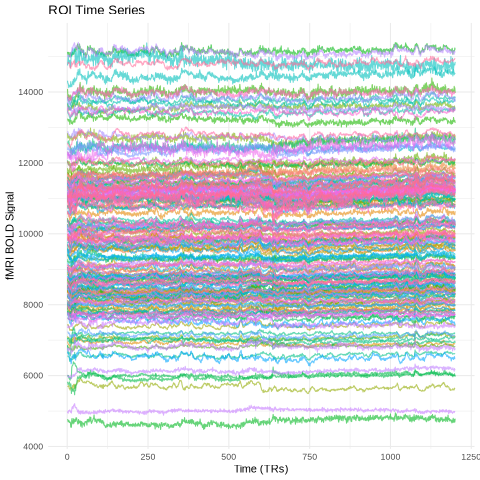

In [11]:
%%R
# Add a Time column so we can create a nice labelled plot
df2 <- df
df2$Time <- 1:nrow(df2)

# Reshape data frame to long format
df_long <- pivot_longer(df2, 
                        cols = -Time, 
                        names_to = "Region", 
                        values_to = "Signal")
# Plot
ggplot(df_long, aes(x = Time, y = Signal, color = Region)) +
  geom_line(alpha = 0.6) +
  theme_minimal() +
  labs(title = "ROI Time Series", x = "Time (TRs)", y = "fMRI BOLD Signal") +
  theme(legend.position = "none") 

### Normalize time series data

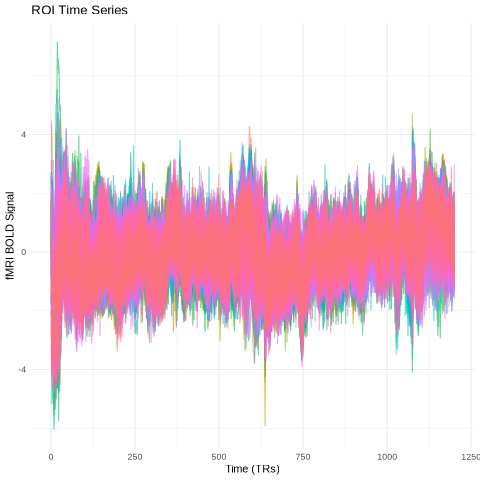

In [12]:
%%R
###First step: normalise their time series data
df_z <- scale(df, center = TRUE, scale = TRUE) 
df_z <- as.data.frame(df_z) #make data frame
  
#Plot df_z
# Add a Time column so we can create a nice labelled plot
df_z$Time <- 1:nrow(df_z)

#Reshape data frame to long format
df_z_long <- pivot_longer(df_z, 
                          cols = -Time, 
                          names_to = "Region", 
                          values_to = "Signal")
#Plot
ggplot(df_z_long, aes(x = Time, y = Signal, color = Region)) +
  geom_line(alpha = 0.6) +
  theme_minimal() +
  labs(title = "ROI Time Series", x = "Time (TRs)", y = "fMRI BOLD Signal") +
  theme(legend.position = "none")

### Calculate their Functional Connectivity (FC) matrix
Let’s do some analyses on these data now! First thing, let’s calculate functional connectivity (FC). As a refresher, FC is a statistical construct derived (typically) as the Pearson’s correlation between pairs of brain regions. The output is therefore a region x region matrix where each entry indicates how strong the correlation is between two regions. In our case, our FC matrix will be 200x200.

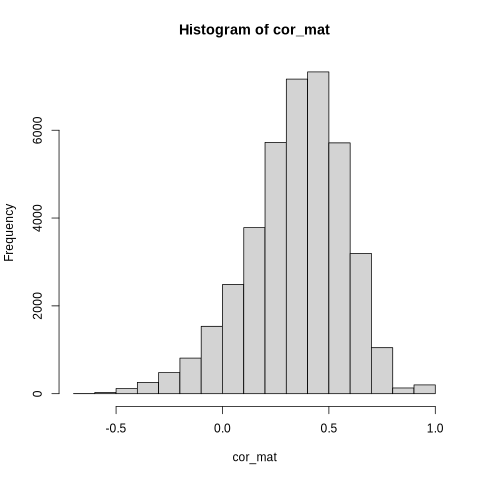

In [13]:
%%R
###Second step: calculate their FC matrix
matrix_df <- as.matrix(df) #convert to matrix format to do calculations

# Pearson's correlation
cor_mat <- cor(matrix_df) #compute FC on matrix format variable

#Look at distribution of FC values
hist(cor_mat) 

### Normalise FC values
For group analyses, we need to normalise these FC values: Fisher-z transformation

In [14]:
%%R
###Third step: normalise their FC values
z_mat <- atanh(cor_mat) 
# Clean matrix: replace Inf values that come from Fisher z-transform
z_mat[!is.finite(z_mat)] <- NA

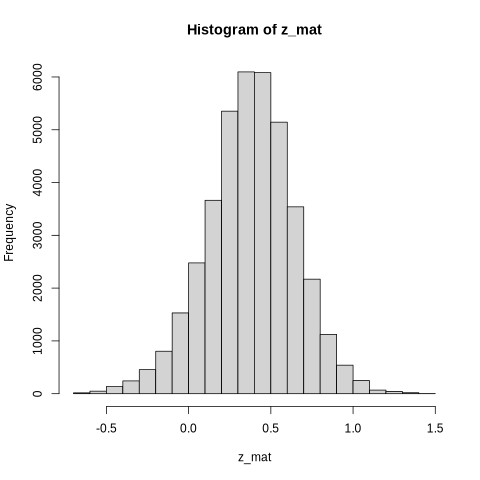

In [15]:
%%R
hist(z_mat)

### Visualise FC matrix
You can play with the value limits, but in generally you want to make sure you see boxes in your matrix reflecting the brain’s functional network organisation.

In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the superheat package.
  Please report the issue to the authors.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


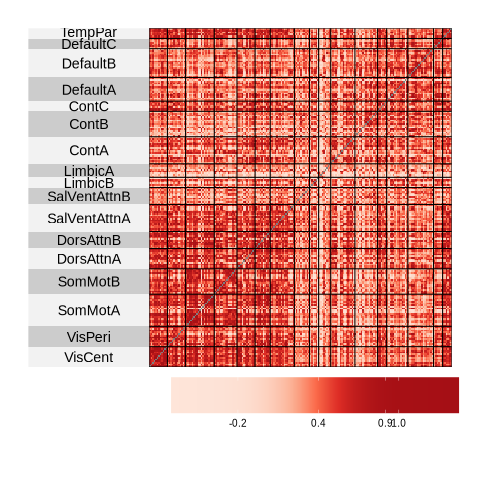

In [16]:
%%R
###Fourth step: roughly visualise their FC matrix

# Use these names to label your FC matrix
colnames(z_mat) <- atlas 
rownames(z_mat) <- atlas 

# Example: "17Networks_LH_VisCent_ExStr_1" → "VisCent"
networks <- sub("17Networks_.._([^_]+).*", "\\1", atlas)
networks <- factor(networks, levels = unique(networks))

reds <- colorRampPalette(c("#fee5d9", "#fcae91", "#fb6a4a", "#de2d26", "#a50f15"))(100)
superheat(z_mat,
          membership.rows = networks,
          membership.cols = networks,
          left.label.size = 0.4,
          bottom.label.size = 0,
          scale = FALSE,
          heat.pal = reds,
          # make the legend bigger
          legend.height = 0.25,
          legend.width = 2,
          legend.text.size = 10)

### Calculate Nodal strength
Let’s take this a step further. Let’s calculate how much each region is connected to the rest of the brain, a measure that is called node strength. [Node strength](https://sites.google.com/site/bctnet/list-of-measures), or region strength, is “the sum of weights of links connected to the node”. This will allow us to obtain a 1x200 vector that we can relate to a bunch of other measures of brain organisation.

In [17]:
%%R
###Fifth step: calculate nodal strength
node_strength <- rowSums(z_mat, na.rm = TRUE)

node_strength <- as.data.frame(node_strength)
rownames(node_strength) <- seq(1:200)

node_strength[,2] <- atlas

colnames(node_strength)[1] <- "Value"
colnames(node_strength)[2] <- "region"

Merging atlas and data by region and label.


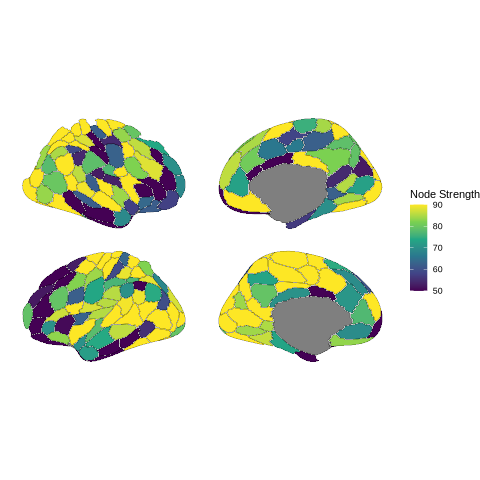

In [18]:
%%R

options(repr.plot.width = 20, repr.plot.height = 8)

node_strength %>%
  mutate(label = case_when(
    grepl("^17Networks_LH", region) ~ paste0("lh_", region),
    grepl("^17Networks_RH", region) ~ paste0("rh_", region),
    TRUE ~ region
  )) %>%
  ggplot() +
  geom_brain(atlas = schaefer17_200(),
             position = position_brain(hemi ~ view, 
                                       view = c("lateral", "medial")),
             mapping = aes(fill = Value),
             colour = "black",
             size = 0.1) +
  scale_fill_viridis_c(limits = c(50, 90), oob = scales::squish) +
  theme_void() +
  labs(fill = "Node Strength")

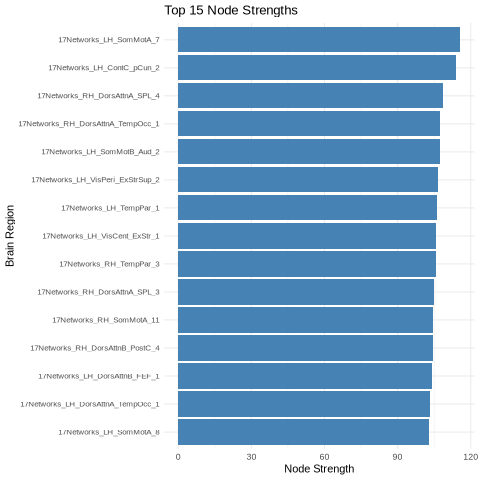

In [19]:
%%R
top_n <- 15  

node_strength %>%
  slice_max(Value, n = top_n) %>%
  ggplot(aes(x = reorder(region, Value), y = Value)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = paste("Top", top_n, "Node Strengths"),
       x = "Brain Region",
       y = "Node Strength") +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 8))


### Relate their nodal strength measures to measures of brain organisation and gene organisation

In [20]:
%%R
###Sixth step: relate their nodal strength measures to measures of brain organisation and gene organisation
brain_organisation <- read.csv("./data/margulies2016_fcgradient01_20017Schaefer.csv")
gene_organisation <- read.csv("./data/gene_pc1_20017Schaefer.csv")

Merging atlas and data by region and label.


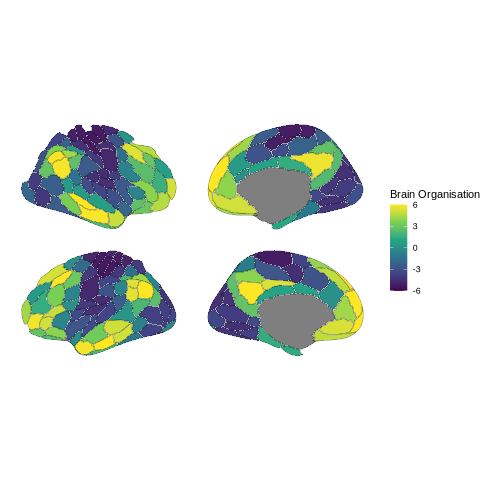

In [21]:
%%R

brain_organisation %>%
  mutate(label = case_when(
    grepl("^17Networks_LH", region) ~ paste0("lh_", region),
    grepl("^17Networks_RH", region) ~ paste0("rh_", region),
    TRUE ~ region
  )) %>%
  ggplot() +
  geom_brain(atlas = schaefer17_200(),
             position = position_brain(hemi ~ view,
                                       view = c("lateral", "medial")),
             mapping = aes(fill = Value),
             colour = "black",
             size = 0.1) +
  scale_fill_viridis_c(limits = c(-6, 6), oob = scales::squish) +
  theme_void() +
  labs(fill = "Brain Organisation")

Merging atlas and data by region and label.


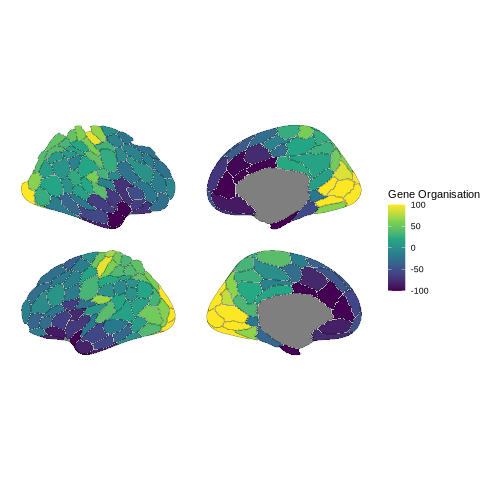

In [22]:
%%R

gene_organisation %>%
  mutate(label = case_when(
    grepl("^17Networks_LH", region) ~ paste0("lh_", region),
    grepl("^17Networks_RH", region) ~ paste0("rh_", region),
    TRUE ~ region
  )) %>%
  ggplot() +
  geom_brain(atlas = schaefer17_200(),
             position = position_brain(hemi ~ view,
                                       view = c("lateral", "medial")),
             mapping = aes(fill = Value),
             colour = "black",
             size = 0.1) +
  scale_fill_viridis_c(limits = c(-100, 100), oob = scales::squish) +
  theme_void() +
  labs(fill = "Gene Organisation")


In [23]:
%%R
#Compute correlation amongst these vectors: nodal strength, brain organisation and gene organisation
corr_node_brainorg <- cor(node_strength$Value,brain_organisation$Value, method = 'spearman') 
corr_node_geneorg <- cor(node_strength$Value,gene_organisation$Value, method = 'spearman')

In [24]:
%%R
# Put results into a data frame
cor_results <- data.frame(
  Comparison = c("Nodal Strength vs Brain Organisation",
                 "Nodal Strength vs Gene Organisation"),
  Spearman_rho = c(corr_node_brainorg, corr_node_geneorg)
)

library(knitr)
kable(cor_results, digits = 3, caption = "Spearman correlations for Nodal Strength")



Table: Spearman correlations for Nodal Strength

|Comparison                           | Spearman_rho|
|:------------------------------------|------------:|
|Nodal Strength vs Brain Organisation |       -0.359|
|Nodal Strength vs Gene Organisation  |        0.459|


#### Complete session information for reproducibility


In [25]:
%%R
cat("=== R Session Information ===\n\n")
sessionInfo()

=== R Session Information ===

R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] tools     stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] knitr_1.51          tidyr_1.3.2         dplyr_1.2.1        
 [4] ggplot2_4.0.3       superheat_0.1.0     s2_1.1.11          
 [7] units_1.0-1         sf_1.1-0            ggsegSchaefer_2.0.0
[10] ggseg_2.1.1        

loaded via a namespace (and not attached):
 [1] gtable_0.3.6        compiler_4.5.3      tidy

In [26]:
import os

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)

print(f"Neurodesktop version: {neurodesktop_version}")

Neurodesktop version: 2026-06-13
